In [ ]:
import polars as pl
from pathlib import Path
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np
from procompa.helpers import clean_identifiers
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [ ]:
'''
# load and concatinate the complexes from both prts of running the benchmark
benchmark_structure_similarity_p1 = pl.read_parquet(data_dir / "Pipeline/7_benchmark_part_one/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
benchmark_structure_similarity_p2 = pl.read_parquet(data_dir / "Pipeline/8_benchmark_part_two/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")

benchmark_structure_similarity_p1 = benchmark_structure_similarity_p1.with_columns(
    benchmark_part=pl.lit(1)
)
benchmark_structure_similarity_p2 = benchmark_structure_similarity_p2.with_columns(
    benchmark_part=pl.lit(2)
)
benchmark_structure_similarity = pl.concat([benchmark_structure_similarity_p1, benchmark_structure_similarity_p2], how="vertical")

# add celaned indtifiers and whetehr the comple has an intresting stoichiometry
benchmark_structure_similarity = clean_identifiers(benchmark_structure_similarity, "identifiers")
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    pl.col("CP_stochiometry").map_elements(lambda s: any(v > 1 for v in json.loads(s).values()), return_dtype=pl.Boolean).alias("interesting_stoichiometry")
)

# add Cf output for eahc row
conf = {}
for d in {Path(p).parent for p in benchmark_structure_similarity["combfold_output_path"]}:
    conf.update(dict(line.split() for line in open(d / "confidence.txt")))

benchmark_structure_similarity = benchmark_structure_similarity.with_columns(pl.col("combfold_output_path").map_elements(lambda p: float(conf[p]), return_dtype=pl.Float64).alias("CF_confidence"))
#benchmark_structure_similarity.write_parquet(data_dir / "Pipeline/8_benchmark_part_two/cf_pdb_structure_similarity/both_parts_benchmark_structure_similarity.parquet")
'''

In [ ]:
benchmark_structure_similarity = pl.read_parquet(data_dir / "Pipeline/8_benchmark_part_two/cf_pdb_structure_similarity/both_parts_benchmark_structure_similarity.parquet")


In [ ]:
# get one row per complex 
benchmark_structure_similarity_one_per_complex = benchmark_structure_similarity.sort("usalign_cpx_tm_score", descending=True).group_by("complex_ac").first()

## Tables

In [ ]:
# big complex with intr stoi
cols = ["complex_ac", "identifiers", "n_proteins"]

table_df = benchmark_structure_similarity_one_per_complex.filter(
    (pl.col("n_proteins") > 2) & (pl.col("interesting_stoichiometry") == True)
).select(cols)

table_df = table_df.with_columns(
    pl.col("identifiers")
    .str.split("|")
    .list.eval(
        pl.element().filter(
            ~pl.element().str.starts_with("CHEBI") & ~pl.element().str.starts_with("URS")
        )
    )
    .alias("_filtered_ids")
)

table_df = table_df.with_columns(
    _filtered_ids=pl.col("_filtered_ids").list.join("|"),
    n_proteins=pl.col("_filtered_ids").list.len(),  # recompute from filtered list
).drop("identifiers").rename({"_filtered_ids": "identifiers"}).select(cols)

pdf = table_df.to_pandas().round(3).astype(str)

def wrap_pipe_delimited(s, max_width=40):
    parts = s.split("|")
    lines, current = [], ""
    for p in parts:
        candidate = f"{current}|{p}" if current else p
        if len(candidate) > max_width and current:
            lines.append(current)
            current = p
        else:
            current = candidate
    if current:
        lines.append(current)
    return "\n".join(lines)

pdf["identifiers"] = pdf["identifiers"].apply(wrap_pipe_delimited)

n_lines_per_row = pdf["identifiers"].str.count("\n") + 1
header_lines = 1
total_lines = n_lines_per_row.sum() + header_lines

line_height_in = 0.28
fig_height = line_height_in * total_lines + 0.5
fig, ax = plt.subplots(figsize=(8, fig_height))
ax.axis("off")

tab = ax.table(
    cellText=pdf.values,
    colLabels=cols,
    cellLoc="center",
    loc="center",
    colWidths=[0.2, 0.6, 0.20],
    bbox=[0, 0, 1, 1],
)
tab.auto_set_font_size(False)
tab.set_fontsize(10)

for row_idx in range(len(pdf) + 1):
    frac = (header_lines if row_idx == 0 else n_lines_per_row.iloc[row_idx - 1]) / total_lines
    for col_idx in range(len(cols)):
        tab[row_idx, col_idx].set_height(frac)

#plt.tight_layout()
#plt.savefig("cf_pdb_eval_table.png", dpi=300, bbox_inches="tight")
plt.close(fig)

How well does stoic work

In [ ]:
# did stoic get it gor complexes that werent in training 
#interesting complexes (so stoi interesting and n_prot >2)

cols = ["complex_ac", "identifiers", "correct_pred_rank"]

table_df = benchmark_structure_similarity_one_per_complex.filter(
    pl.col("pdb_with_identical_proteins_set_to_CF_in_stoic") == False
).select(cols)

table_df = table_df.with_columns(
    pl.col("identifiers")
    .str.split("|")
    .list.eval(pl.element().filter(~pl.element().str.starts_with("CHEBI")))
    .list.join("|")
    .alias("identifiers")
)

pdf = table_df.to_pandas().round(3).astype(str)

def wrap_pipe_delimited(s, max_width=50):
    parts = s.split("|")
    lines, current = [], ""
    for p in parts:
        candidate = f"{current}|{p}" if current else p
        if len(candidate) > max_width and current:
            lines.append(current)
            current = p
        else:
            current = candidate
    if current:
        lines.append(current)
    return "\n".join(lines)

pdf["identifiers"] = pdf["identifiers"].apply(wrap_pipe_delimited)

n_lines_per_row = pdf["identifiers"].str.count("\n") + 1
header_lines = 1
total_lines = n_lines_per_row.sum() + header_lines

  
line_height_in = 0.28
fig_height = line_height_in * total_lines + 0.5
fig, ax = plt.subplots(figsize=(10, fig_height))
ax.axis("off")

tab = ax.table(
    cellText=pdf.values,
    colLabels=cols,
    cellLoc="center",
    loc="center",
    colWidths=[0.25, 0.5, 0.25],
    bbox=[0, 0, 1, 1],
)
tab.auto_set_font_size(False)
tab.set_fontsize(10)

for row_idx in range(len(pdf) + 1):
    frac = (header_lines if row_idx == 0 else n_lines_per_row.iloc[row_idx - 1]) / total_lines
    for col_idx in range(len(cols)):
        tab[row_idx, col_idx].set_height(frac)

#plt.tight_layout()
#plt.show()
plt.close(fig)


In [ ]:
#interesting complexes (so stoi interesting and n_prot >2)

benchmark_structure_similarity_intr = (
    benchmark_structure_similarity
    .filter(
        (pl.col("interesting_stoichiometry") == True) &
        (pl.col("n_proteins") > 2)
    )
    .sort("usalign_cpx_tm_score", descending=True)
    .group_by("complex_ac")
    .first()
    .sort("usalign_cpx_tm_score", descending=True)  # re-sort after group_by
)
cols = ["complex_ac","n_proteins", "usalign_cpx_aligned_length", "usalign_cpx_rmsd", "usalign_cpx_seq_id", "usalign_cpx_tm_score"]

table_df = benchmark_structure_similarity_intr.select(cols)

fig, ax = plt.subplots(figsize=(3 * len(cols), 0.4 * len(table_df) + 1))
ax.axis("off")

tab = ax.table(
    cellText=table_df.to_pandas().round(3).astype(str).values,
    colLabels=cols,
    cellLoc="center",
    loc="center",
)
tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.5)

#plt.savefig("cf_pdb_eval_table.png", dpi=300, bbox_inches="tight")


## How much does the CF output differ for one CF run

In [ ]:
benchmark_structure_similarity_big_complexes = benchmark_structure_similarity.filter(pl.col("n_proteins") > 2)
summary_tm_conf = benchmark_structure_similarity_big_complexes.group_by("complex_ac").agg(
    (pl.col("usalign_cpx_tm_score").max() - pl.col("usalign_cpx_tm_score").min()).alias("tm_score_range"),
    (pl.col("CF_confidence").max() - pl.col("CF_confidence").min()).alias("confidence_range"),
    pl.len().alias("n_outputs"),
    pl.col("interesting_stoichiometry").first(),
).filter(pl.col("n_outputs") > 1)


n_above = (summary_tm_conf["tm_score_range"] > 0.1).sum()

colors = summary_tm_conf["interesting_stoichiometry"].map_elements(
    lambda x: "crimson" if x else "steelblue", return_dtype=pl.String
)

plt.scatter(summary_tm_conf["confidence_range"], summary_tm_conf["tm_score_range"], c=colors)
plt.axhline(0.05, color="grey", linestyle="--")
plt.ylabel("Δ TM score")
plt.xlabel("Δ confidence")
n_total = summary_tm_conf.height
plt.legend([f"{n_above}/{n_total} complexes > 0.1 Δ TM score"], loc="upper right")
plt.show()

In [ ]:
summary_tm_conf = benchmark_structure_similarity.group_by("complex_ac").agg(
    (pl.col("usalign_cpx_tm_score").max() - pl.col("usalign_cpx_tm_score").min()).alias("tm_score_range"),
    (pl.col("CF_confidence").max() - pl.col("CF_confidence").min()).alias("confidence_range"),
    pl.len().alias("n_outputs"),
    (pl.col("n_proteins").first() > 2).alias("many_proteins"),
    pl.col("interesting_stoichiometry").first().alias("interesting_stoichiometry"),
).filter(pl.col("n_outputs") > 1)

n_above = (summary_tm_conf["tm_score_range"] > 0.1).sum()
n_total = summary_tm_conf.height

summary_tm_conf = summary_tm_conf.with_columns(
    pl.when(pl.col("many_proteins") & pl.col("interesting_stoichiometry"))
    .then(pl.lit("both"))
    .when(pl.col("many_proteins"))
    .then(pl.lit("many proteins"))
    .otherwise(pl.lit("neither"))
    .alias("category")
)

cmap = {"neither": "tab:blue", "many proteins": "tab:orange", "both": "tab:red"}
order = ["neither", "many proteins", "both"]
counts = dict(zip(*summary_tm_conf["category"].value_counts().to_dict(as_series=False).values()))



labels = {"neither": "neither", "many proteins": ">2 prot", "both": ">2 prot and intr. stoi"}

fig, ax = plt.subplots()
ax.scatter(
    summary_tm_conf["confidence_range"],
    summary_tm_conf["tm_score_range"],
    c=[cmap[c] for c in summary_tm_conf["category"]],
)
ax.axhline(0.05, color="grey", linestyle="--")
ax.set_ylabel("Δ TM score")
ax.set_xlabel("Δ confidence")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=cmap[cat], label=f"{labels[cat]} (n={counts.get(cat, 0)})") for cat in order
])
plt.show()



In [ ]:
benchmark_structure_similarity_big_complexes = benchmark_structure_similarity.filter(pl.col("n_proteins") > 2)
summary_rmsd_conf = benchmark_structure_similarity_big_complexes.group_by("complex_ac").agg(
    (pl.col("usalign_cpx_rmsd").max() - pl.col("usalign_cpx_rmsd").min()).alias("rmsd_score_range"),
    (pl.col("CF_confidence").max() - pl.col("CF_confidence").min()).alias("confidence_range"),
    pl.len().alias("n_outputs"),
    pl.col("interesting_stoichiometry").first(),
).filter(pl.col("n_outputs") > 1)

n_above = (summary_rmsd_conf["rmsd_score_range"] > 1).sum()

colors = summary_rmsd_conf["interesting_stoichiometry"].map_elements(
    lambda x: "crimson" if x else "steelblue", return_dtype=pl.String
)

plt.scatter(summary_rmsd_conf["confidence_range"], summary_rmsd_conf["rmsd_score_range"], c=colors)
plt.axhline(1, color="grey", linestyle="--")
plt.xlabel("Δ confidence")
plt.ylabel("Δ RMSD")
n_total = summary_rmsd_conf.height
plt.legend([f"{n_above}/{n_total} complexes above Δ  1 RMSD"])
plt.show()

In [ ]:
summary_rmsd_conf = benchmark_structure_similarity.group_by("complex_ac").agg(
    (pl.col("usalign_cpx_rmsd").max() - pl.col("usalign_cpx_rmsd").min()).alias("rmsd_score_range"),
    (pl.col("CF_confidence").max() - pl.col("CF_confidence").min()).alias("confidence_range"),
    pl.len().alias("n_outputs"),
    (pl.col("n_proteins").first() > 2).alias("many_proteins"),
    pl.col("interesting_stoichiometry").first().alias("interesting_stoichiometry"),
).filter(pl.col("n_outputs") > 1)

n_above = (summary_rmsd_conf["rmsd_score_range"] > 0.1).sum()
n_total = summary_rmsd_conf.height

summary_rmsd_conf = summary_rmsd_conf.with_columns(
    pl.when(pl.col("many_proteins") & pl.col("interesting_stoichiometry"))
    .then(pl.lit("both"))
    .when(pl.col("many_proteins"))
    .then(pl.lit("many proteins"))
    .otherwise(pl.lit("neither"))
    .alias("category")
)

cmap = {"neither": "tab:blue", "many proteins": "tab:orange", "both": "tab:red"}
order = ["neither", "many proteins", "both"]
counts = dict(zip(*summary_rmsd_conf["category"].value_counts().to_dict(as_series=False).values()))



labels = {"neither": "neither", "many proteins": ">2 prot", "both": ">2 prot and intr. stoi"}

fig, ax = plt.subplots()
ax.scatter(
    summary_rmsd_conf["confidence_range"],
    summary_rmsd_conf["rmsd_score_range"],
    c=[cmap[c] for c in summary_rmsd_conf["category"]],
)
ax.axhline(0.05, color="grey", linestyle="--")
ax.set_ylabel("Δ RMSD")
ax.set_xlabel("Δ confidence")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=cmap[cat], label=f"{labels[cat]} (n={counts.get(cat, 0)})") for cat in order
])
plt.show()



In [ ]:
benchmark_structure_similarity.columns

In [ ]:
benchmark_structure_similarity_bigger_complexes = benchmark_structure_similarity.filter(pl.col("n_proteins")>2)

rho, pval = spearmanr(
    benchmark_structure_similarity_bigger_complexes["CF_confidence"],
    benchmark_structure_similarity_bigger_complexes["usalign_cpx_tm_score"],
)
n = len(benchmark_structure_similarity_bigger_complexes)

plt.scatter(
    benchmark_structure_similarity_bigger_complexes["CF_confidence"],
    benchmark_structure_similarity_bigger_complexes["usalign_cpx_tm_score"],
    label=f"n = {n}\nSpearman ρ = {rho:.2f}",
)
plt.xlabel("CF confidence")
plt.ylabel("TM Score")
plt.title("TM Score for different CF confidence levels all complexes")
plt.legend()
plt.show()

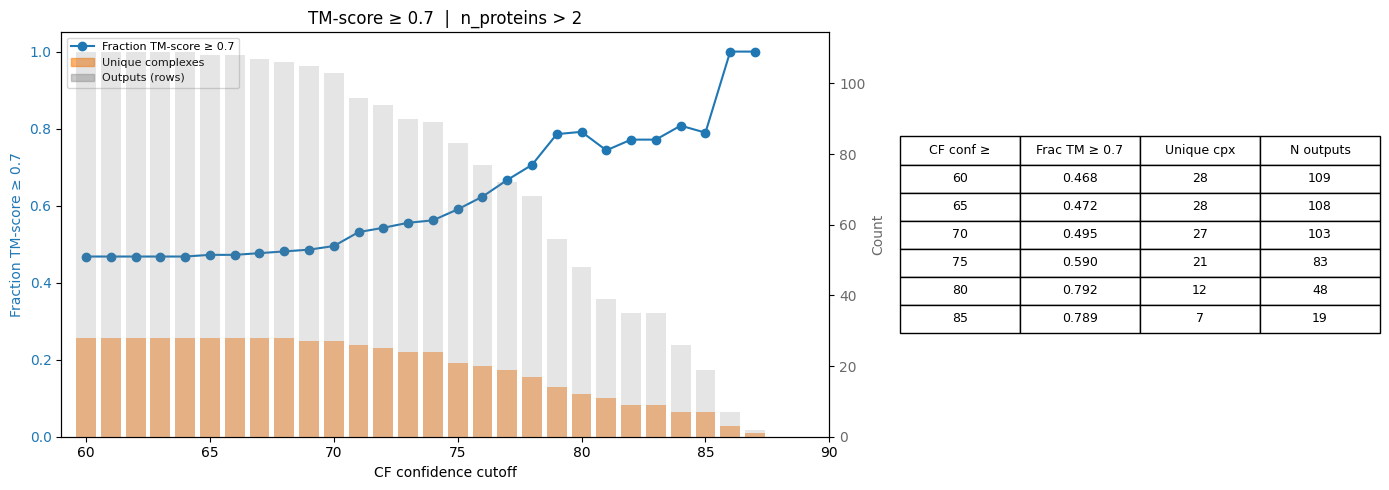

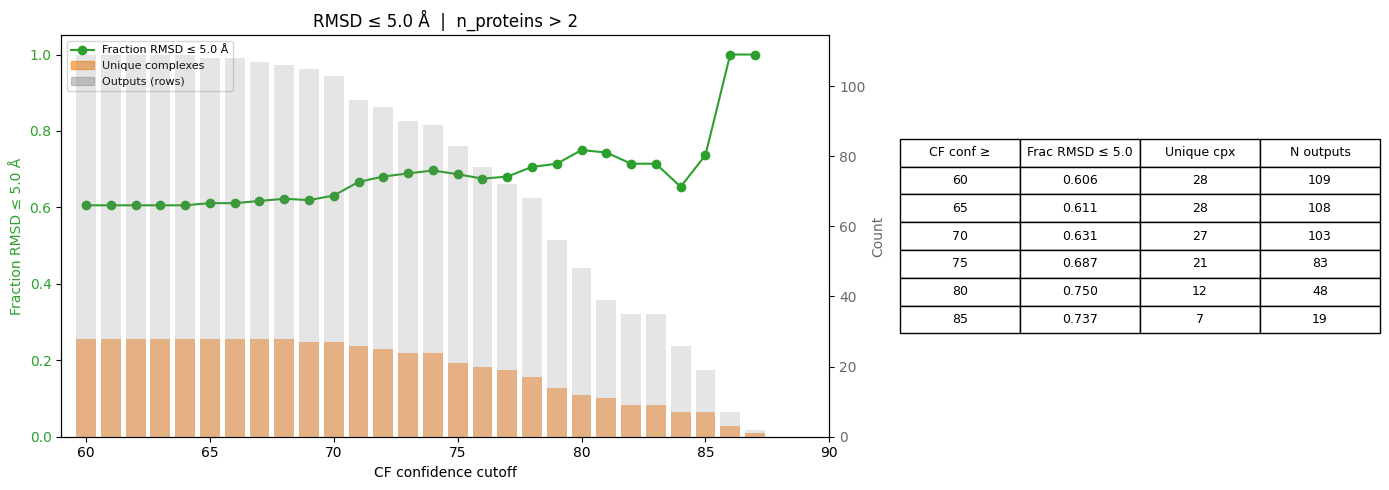

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import polars as pl

TM_TARGET   = 0.7
RMSD_TARGET = 5.0
df_big = benchmark_structure_similarity.filter(pl.col('n_proteins') > 2)

# ── helpers ───────────────────────────────────────────────────────────────────
def precision_vs_cutoff(df, metric_col, target, higher_is_better=True,
                        thresholds=np.arange(60, 90, 1)):
    rows = []
    for t in thresholds:
        sub = df.filter(pl.col('CF_confidence') >= t)
        n_out = len(sub)
        n_cpx = sub['complex_ac'].n_unique() if n_out > 0 else 0
        if n_out > 0:
            prec = float((sub[metric_col] >= target if higher_is_better
                          else sub[metric_col] <= target).mean())
        else:
            prec = None
        rows.append((t, prec, n_cpx, n_out))
    return rows

def add_plot(ax1, rows, ylabel, color):
    thresholds_v, precisions, n_complexes_v, n_outputs_v = zip(*rows)
    ax1.plot(thresholds_v, precisions, marker='o', color=color)
    ax1.set_xlabel('CF confidence cutoff')
    ax1.set_ylabel(ylabel, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(0, 1.05)
    ax1.set_xlim(59, max(thresholds_v) + 1)
    ax2 = ax1.twinx()
    ax2.bar(thresholds_v, n_complexes_v, alpha=0.5, color='tab:orange', width=0.8)
    ax2.bar(thresholds_v, n_outputs_v,   alpha=0.2, color='tab:gray',   width=0.8)
    ax2.set_ylabel('Count', color='dimgray')
    ax2.tick_params(axis='y', labelcolor='dimgray')
    ax1.legend(handles=[
        plt.Line2D([0],[0], marker='o', color=color, label=ylabel),
        Patch(color='tab:orange', alpha=0.6, label='Unique complexes'),
        Patch(color='tab:gray',   alpha=0.4, label='Outputs (rows)'),
    ], loc='upper left', fontsize=8)

def add_table(ax, rows, frac_label):
    lookup = {int(r[0]): r for r in rows}
    cols = ['CF conf ≥', frac_label, 'Unique cpx', 'N outputs']
    cells = []
    for t in [60, 65, 70, 75, 80, 85]:https://www.redbubble.com/shop/cat+vomiting+stickers
        r = lookup.get(t)
        if r:
            prec = f'{r[1]:.3f}' if r[1] is not None else 'nan'
            cells.append([str(t), prec, str(r[2]), str(r[3])])
    ax.axis('off')
    tab = ax.table(cellText=cells, colLabels=cols, cellLoc='center', loc='center')
    tab.auto_set_font_size(False)
    tab.set_fontsize(9)
    tab.scale(1, 1.6)

# ── TM-score ──────────────────────────────────────────────────────────────────
rows_tm = precision_vs_cutoff(df_big, 'usalign_cpx_tm_score', TM_TARGET, higher_is_better=True)

fig, (ax_plot, ax_tab) = plt.subplots(1, 2, figsize=(14, 5),
                                       gridspec_kw={'width_ratios': [1.6, 1]})
add_plot(ax_plot, rows_tm, f'Fraction TM-score ≥ {TM_TARGET}', 'tab:blue')
ax_plot.set_title(f'TM-score ≥ {TM_TARGET}  |  n_proteins > 2')
add_table(ax_tab, rows_tm, f'Frac TM ≥ {TM_TARGET}')
fig.tight_layout()
plt.show()

# ── RMSD ──────────────────────────────────────────────────────────────────────
rows_rmsd = precision_vs_cutoff(df_big, 'usalign_cpx_rmsd', RMSD_TARGET, higher_is_better=False)

fig, (ax_plot, ax_tab) = plt.subplots(1, 2, figsize=(14, 5),
                                       gridspec_kw={'width_ratios': [1.6, 1]})
add_plot(ax_plot, rows_rmsd, f'Fraction RMSD ≤ {RMSD_TARGET} Å', 'tab:green')
ax_plot.set_title(f'RMSD ≤ {RMSD_TARGET} Å  |  n_proteins > 2')
add_table(ax_tab, rows_rmsd, f'Frac RMSD ≤ {RMSD_TARGET}')
fig.tight_layout()
plt.show()

In [ ]:
#TM score
thresholds = np.arange(50, 95, 1)
tm_target = 0.7

results = []
for t in thresholds:
    sub = benchmark_structure_similarity_bigger_complexes.filter(pl.col("CF_confidence") >= t)
    if len(sub) == 0:
        continue
    precision = (sub["usalign_cpx_tm_score"] >= tm_target).mean()
    results.append((t, precision, len(sub)))

#for t, p, n in results:
#    print(f"conf>={t}: {p:.2%} above TM {tm_target} (n={n})")

thresholds, precisions, ns = zip(*results)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(thresholds, precisions, marker="o", color="tab:blue", label="Precision")
ax1.set_xlabel("CF confidence cutoff")
ax1.set_ylabel(f"Fraction with TM-score ≥ {tm_target}", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.bar(thresholds, ns, alpha=0.2, color="tab:gray", width=0.8, label="n complexes")
ax2.set_ylabel("Number of complexes (n)", color="tab:gray")
ax2.tick_params(axis="y", labelcolor="tab:gray")
ax1.set_xlim(60, max(thresholds))

#plt.title(f"Precision vs. CF confidence cutoff (TM-score ≥ {tm_target})")
fig.tight_layout()
plt.show()

thresholds_5 = np.arange(60, 95, 5)
tm_target = 0.7

rows = []
for t in thresholds_5:
    sub = benchmark_structure_similarity.filter(pl.col("CF_confidence") >= t)
    n = len(sub)
    precision = (sub["usalign_cpx_tm_score"] >= tm_target).mean() if n > 0 else None
    rows.append((int(t), precision, n))

table_df = pl.DataFrame(
    rows, schema=["CF confidence ≥", f"Fraction TM ≥ {tm_target}", "n"], orient="row"
).with_columns(pl.col(f"Fraction TM ≥ {tm_target}").round(3))

pdf = table_df.to_pandas().astype(str)

fig, ax = plt.subplots(figsize=(5, 0.4 * len(pdf) + 1))
ax.axis("off")

tab = ax.table(
    cellText=pdf.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center",
)
tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.5)

#plt.savefig("cf_confidence_precision_table.png", dpi=300, bbox_inches="tight")
#plt.close(fig)

In [ ]:
#RMSD for different CF confidence levels for complexes with more than 2 proteins
thresholds = np.arange(50, 95, 1)
rmsd_target = 5

results = []
for t in thresholds:
    sub = benchmark_structure_similarity_bigger_complexes.filter(pl.col("CF_confidence") >= t)
    if len(sub) == 0:
        continue
    precision = (sub["usalign_cpx_rmsd"] <= rmsd_target).mean()
    results.append((t, precision, len(sub)))

#for t, p, n in results:
#    print(f"conf>={t}: {p:.2%} below RMSD {rmsd_target} (n={n})")

thresholds, precisions, ns = zip(*results)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(thresholds, precisions, marker="o", color="tab:blue", label="Precision")
ax1.set_xlabel("CF confidence cutoff")
ax1.set_ylabel(f"Fraction with RMSD ≤ {rmsd_target}", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.bar(thresholds, ns, alpha=0.2, color="tab:gray", width=0.8, label="n complexes")
ax2.set_ylabel("Number of complexes (n)", color="tab:gray")
ax2.tick_params(axis="y", labelcolor="tab:gray")
ax1.set_xlim(60, max(thresholds))

#plt.title(f"Precision vs. CF confidence cutoff (RMSD ≤ {rmsd_target})")
fig.tight_layout()
plt.show()

thresholds_5 = np.arange(60, 95, 5)
rmsd_target = 5

rows = []
for t in thresholds_5:
    sub = benchmark_structure_similarity_bigger_complexes.filter(pl.col("CF_confidence") >= t)
    n = len(sub)
    precision = (sub["usalign_cpx_rmsd"] <= rmsd_target).mean() if n > 0 else None
    rows.append((int(t), precision, n))

table_df = pl.DataFrame(
    rows, schema=["CF confidence ≥", f"Fraction RMSD ≤ {rmsd_target}", "n"], orient="row"
).with_columns(pl.col(f"Fraction RMSD ≤ {rmsd_target}").round(3))

pdf = table_df.to_pandas().astype(str)

fig, ax = plt.subplots(figsize=(5, 0.4 * len(pdf) + 1))
ax.axis("off")

tab = ax.table(
    cellText=pdf.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center",
)
tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.5)

#plt.savefig("cf_confidence_precision_table.png", dpi=300, bbox_inches="tight")
#plt.close(fig)

In [ ]:
import numpy as np

thresholds = np.arange(50, 95, 1)
rmsd_target = 5

results = []
for t in thresholds:
    sub = benchmark_structure_similarity_bigger_complexes.filter(pl.col("CF_confidence") >= t)
    if len(sub) == 0:
        continue
    precision = (sub["usalign_cpx_rmsd"] <= rmsd_target).mean()
    results.append((t, precision, len(sub)))

for t, p, n in results:
    print(f"conf>={t}: {p:.2%} below RMSD {rmsd_target} (n={n})")

thresholds, precisions, ns = zip(*results)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(thresholds, precisions, marker="o", color="tab:blue", label="Precision")
ax1.set_xlabel("CF confidence cutoff")
ax1.set_ylabel(f"Fraction with RMSD ≤ {rmsd_target}", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.bar(thresholds, ns, alpha=0.2, color="tab:gray", width=0.8, label="n complexes")
ax2.set_ylabel("Number of complexes (n)", color="tab:gray")
ax2.tick_params(axis="y", labelcolor="tab:gray")
ax1.set_xlim(60, max(thresholds))

plt.title(f"Precision vs. CF confidence cutoff (RMSD ≤ {rmsd_target})")
fig.tight_layout()
plt.show()

In [ ]:
plot_df = benchmark_structure_similarity.with_columns(
    (pl.col("n_proteins") > 2).alias("many_proteins"),
).with_columns(
    pl.when(pl.col("many_proteins") & pl.col("interesting_stoichiometry"))
    .then(pl.lit("both"))
    .when(pl.col("many_proteins"))
    .then(pl.lit("many proteins"))
    .otherwise(pl.lit("neither"))
    .alias("category")
)

cmap = {"neither": "tab:blue", "many proteins": "tab:orange", "both": "tab:red"}
labels = {"neither": "neither", "many proteins": ">2 prot", "both": ">2 prot and intr. stoi"}
order = ["neither", "many proteins", "both"]
counts = dict(zip(*plot_df["category"].value_counts().to_dict(as_series=False).values()))

fig, ax = plt.subplots()
ax.scatter(
    plot_df["CF_confidence"],
    plot_df["usalign_cpx_tm_score"],
    c=[cmap[c] for c in plot_df["category"]],
)
ax.set_xlabel("CF confidence")
ax.set_ylabel("TM-score")
ax.set_title("TM-scores for different CF confidence levels")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=cmap[cat], label=f"{labels[cat]} (n={counts.get(cat, 0)})") for cat in order
])
plt.show()

In [ ]:
plt.scatter(benchmark_structure_similarity["CF_confidence"], benchmark_structure_similarity["usalign_cpx_rmsd"])
plt.xlabel("CF confidence")
plt.ylabel("RMSD-score")
plt.title("RMSD-scores for different CF confidence levels")
plt.show()

how does TM behave for differntly sized complexes

In [ ]:
from scipy.stats import spearmanr, pearsonr

x_vals = benchmark_structure_similarity["usalign_cpx_len_structure1"].to_numpy()
y_vals = benchmark_structure_similarity["usalign_cpx_tm_score"].to_numpy()

mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
x_clean, y_clean = x_vals[mask], y_vals[mask]

rho_s, p_s = spearmanr(x_clean, y_clean)
rho_p, p_p = pearsonr(x_clean, y_clean)

plt.scatter(x_vals, y_vals)
plt.xlabel("len")
plt.ylabel("TM-score")
plt.text(
    0.95, 0.95, f"spearman ρ = {rho_s:.2f}",
    transform=plt.gca().transAxes, ha="right", va="top",
    fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)
plt.show()

In [ ]:
"""
n_proteins_bucketed = pl.when(pl.col("n_proteins") >= 7).then(7).otherwise(pl.col("n_proteins"))

stats = benchmark_structure_similarity.filter(pl.col("n_proteins") > 1).with_columns(
    n_proteins_bucketed.alias("n_proteins_group")
).group_by("n_proteins_group").agg(
    pl.len().alias("n_outputs"),
    pl.col("complex_ac").n_unique().alias("n_complexes"),
).sort("n_proteins_group")

df_bucketed = benchmark_structure_similarity.filter(pl.col("n_proteins") > 1).with_columns(n_proteins_bucketed.alias("n_proteins_group"))
groups = [df_bucketed.filter(pl.col("n_proteins_group") == n)["usalign_cpx_tm_score"] for n in stats["n_proteins_group"]]
labels = [f"{'7+' if n == 7 else n}\n({o} outputs, {c} complexes)" for n, o, c in zip(stats["n_proteins_group"], stats["n_outputs"], stats["n_complexes"])]

plt.figure(figsize=(16, 6))
plt.boxplot(groups, tick_labels=labels)
plt.xlabel("n_proteins")
plt.ylabel("TM-score")
plt.show()
"""

Tm scores for all outputs, hightlight the ones where stoi is intresting

## Does CF places the correct pairs closeby

In [ ]:
import json

def make_pair_simple(key: str) -> frozenset:
    a, b = key.split("_")
    return frozenset([a, b])

def pairset(d) -> set[frozenset]:
    if isinstance(d, str):
        d = json.loads(d)
    return {make_pair_simple(k) for k in d}

def compare_chainpairs_row(cf_dict, ref_dict) -> dict:
    cf_pairs = pairset(cf_dict)
    ref_pairs = pairset(ref_dict)
    return {
        "n_cf": len(cf_pairs),
        "n_ref": len(ref_pairs),
        "n_cf_in_ref": len(cf_pairs & ref_pairs),
        "n_cf_extra": len(cf_pairs - ref_pairs),
        "n_ref_missing": len(ref_pairs - cf_pairs),
    }

In [ ]:
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    pl.struct(["cf_close_by_chainpairs", "ref_close_by_chainpairs"])
    .map_elements(
        lambda row: compare_chainpairs_row(
            row["cf_close_by_chainpairs"], row["ref_close_by_chainpairs"]
        ),
        return_dtype=pl.Struct({
            "n_cf": pl.UInt32,
            "n_ref": pl.UInt32,
            "n_cf_in_ref": pl.UInt32,
            "n_cf_extra": pl.UInt32,
            "n_ref_missing": pl.UInt32,
        }),
    )
    .alias("chainpair_overlap")
).unnest("chainpair_overlap")

# add jaccard
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    (
        pl.col("n_cf_in_ref")
        / (pl.col("n_cf_in_ref") + pl.col("n_cf_extra") + pl.col("n_ref_missing"))
    ).alias("jaccard")
)

In [ ]:
df = benchmark_structure_similarity.filter(pl.col("n_proteins") > 2)

df_sorted = df.sort(["n_proteins", "jaccard"], descending=[False, True])

n = len(df_sorted)
x = np.arange(n)
is_interesting = df_sorted["interesting_stoichiometry"].to_list()

fig, ax = plt.subplots(figsize=(max(8, n * 0.15), 5))

bottoms1 = df_sorted["n_cf_in_ref"]
bottoms2 = bottoms1 + df_sorted["n_cf_extra"]
totals = bottoms2 + df_sorted["n_ref_missing"]

# colored segments, no edges at all
ax.bar(x, df_sorted["n_cf_in_ref"], color="#4CAF50")
ax.bar(x, df_sorted["n_cf_extra"], bottom=bottoms1, color="#E53935")
ax.bar(x, df_sorted["n_ref_missing"], bottom=bottoms2, color="#FB8C00")

# outline only around the full stack, only for interesting-stoichiometry bars
for i in range(n):
    if is_interesting[i]:
        ax.bar(x[i], totals[i], color="none", edgecolor="black", linewidth=1.2, zorder=3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="Correct (CF ∩ ref)"),
    Patch(facecolor="#E53935", label="Extra (CF only)"),
    Patch(facecolor="#FB8C00", label="Missing (pdb ref only)"),
    Patch(facecolor="white", edgecolor="grey", linewidth=1.2, label="Interesting stoichiometry"),
]
ax.legend(handles=legend_elements, loc="upper left")

group_sizes = df_sorted.group_by("n_proteins", maintain_order=True).len()
pos = 0
for row in group_sizes.iter_rows(named=True):
    size, count = row["n_proteins"], row["len"]
    if pos > 0:
        ax.axvline(pos - 0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.text(pos + count / 2, ax.get_ylim()[1] * 0.97, f"n={size}",
            ha="center", va="top", fontsize=8, color="dimgray")
    pos += count

ax.set_xlabel("Complex (grouped by n_proteins, sorted by jaccard within group)")
ax.set_ylabel("Number of chain-pair interfaces")
ax.set_title("Interface prediction breakdown per complex")
ax.set_xticks([])
ax.set_xlim(-0.5, n - 0.5)

plt.tight_layout()
plt.show()

## Add Af metrics

In [ ]:
# load metric only for paiirst that cf places clsoely together
benchmark_structure_similarity = pl.read_parquet(data_dir / "Pipeline/8_benchmark_part_two/cf_pdb_structure_similarity/both_parts_benchmark_structure_similarity.parquet")
metrics = pl.read_csv(data_dir / "Pipeline/8_benchmark_part_two/combined_pool_pairs_metrics_with_plddt.csv")

benchmark_structure_similarity = benchmark_structure_similarity.with_row_index("row_id")

# explode cf_close_by_chainpairs (per CF-output row) into (row_id, complex_ac, pair)
extract_pairs = lambda s: list(json.loads(s).keys()) if s else []
cf_pairs_long = (
    benchmark_structure_similarity
    .select("row_id", "complex_ac", "cf_close_by_chainpairs")
    .with_columns(pl.col("cf_close_by_chainpairs").map_elements(extract_pairs, return_dtype=pl.List(pl.String)).alias("pair"))
    .explode("pair").drop_nulls("pair")
)

# keep only metrics rows whose pair is used by CF *somewhere* — cuts the dataset before any further processing
metrics = metrics.join(cf_pairs_long.select("complex_ac", "pair").unique(), on=["complex_ac", "pair"], how="semi")

# drop pairs with upstream fan-out (>1 row per complex_ac, pair) — now only checked within the relevant subset
dup_pairs = metrics.group_by("complex_ac", "pair").agg(pl.len().alias("n")).filter(pl.col("n") > 1)
print(f"{dup_pairs.height} pairs dropped ({dup_pairs['n'].sum()} rows):\n{dup_pairs}")

clean_metrics = metrics.join(dup_pairs.select("complex_ac", "pair"), on=["complex_ac", "pair"], how="anti")
assert clean_metrics.group_by("complex_ac", "pair").agg(pl.len().max()).select(pl.col("len").max()).item() == 1

# real-homodimer filter
stoich = benchmark_structure_similarity.select("complex_ac", "CP_stochiometry").unique()
is_real_homodimer = lambda r: r["CP_stochiometry"] is not None and json.loads(r["CP_stochiometry"]).get(r["protein1"], 0) >= 2

clean_metrics = clean_metrics.join(stoich, on="complex_ac", how="left").filter(
    (pl.col("pair_type") != "homo")
    | pl.struct("protein1", "CP_stochiometry").map_elements(is_real_homodimer, return_dtype=pl.Boolean)
)

# per-row aggregation (row-specific, since valid pairs differ per CF output) + kicked_out_pair flag
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    pl.col("complex_ac").is_in(dup_pairs["complex_ac"].implode()).alias("kicked_out_pair")
)

metrics_by_row = (
    cf_pairs_long.join(clean_metrics, on=["complex_ac", "pair"], how="inner")
    .group_by("row_id")
    .agg(
        pl.col("pair").alias("af_pairs"),
        *[pl.col(c) for c in ("chain_pair_iptm", "chain_pair_iptm_corrected", "chain_pair_pae_min", "chain_pair_pae_min_recap", "plddt1", "plddt2")],
    )
)

benchmark_structure_similarity = benchmark_structure_similarity.join(metrics_by_row, on="row_id", how="left")

In [ ]:
base_cols = {
    "iptm_corrected": pl.col("chain_pair_iptm_corrected"),
    "pae_min": pl.col("chain_pair_pae_min"),
    "plddt": pl.concat_list(["plddt1", "plddt2"]),
}

aggs = {"min": "min", "mean": "mean", "max": "max"}

benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    [
        getattr(expr.list, agg_method)().alias(f"{name}_{agg_name}")
        for name, expr in base_cols.items()
        for agg_name, agg_method in aggs.items()
    ]
)

metrics = [f"{name}_{agg_name}" for name in base_cols for agg_name in aggs]

from scipy.stats import spearmanr
from matplotlib.patches import Patch

benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    (pl.col("n_proteins") > 2).alias("many_proteins"),
).with_columns(
    pl.when(pl.col("many_proteins") & pl.col("interesting_stoichiometry"))
    .then(pl.lit("both"))
    .when(pl.col("many_proteins"))
    .then(pl.lit("many proteins"))
    .otherwise(pl.lit("neither"))
    .alias("category")
)

cmap = {"neither": "tab:blue", "many proteins": "tab:orange", "both": "tab:red"}
labels = {"neither": "neither", "many proteins": ">2 prot", "both": ">2 prot and intr. stoi"}
order = ["neither", "many proteins", "both"]
counts = dict(zip(*benchmark_structure_similarity["category"].value_counts().to_dict(as_series=False).values()))

colors = [cmap[c] for c in benchmark_structure_similarity["category"]]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, x in zip(axes.flat, metrics):
    x_vals = benchmark_structure_similarity[x].to_numpy()
    y_vals = benchmark_structure_similarity["usalign_cpx_tm_score"].to_numpy()

    mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
    rho, pval = spearmanr(x_vals[mask], y_vals[mask])

    ax.scatter(x_vals, y_vals, c=colors)
    ax.set_xlabel(x)
    ax.set_ylabel("TM-score")
    ax.text(
        0.05, 0.95, f"ρ = {rho:.2f}\np = {pval:.1e}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
    )

fig.legend(
    handles=[Patch(color=cmap[cat], label=f"{labels[cat]} (n={counts.get(cat, 0)})") for cat in order],
    loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3,
)
plt.tight_layout()
plt.show()

In [ ]:
multimers = benchmark_structure_similarity.filter(pl.col("n_proteins") > 2)

base_cols = {
    "iptm_corrected": pl.col("chain_pair_iptm_corrected"),
    "pae_min": pl.col("chain_pair_pae_min"),
    "plddt": pl.concat_list(["plddt1", "plddt2"]),
}

aggs = {"min": "min", "mean": "mean", "max": "max"}

multimers = multimers.with_columns(
    [
        getattr(expr.list, agg_method)().alias(f"{name}_{agg_name}")
        for name, expr in base_cols.items()
        for agg_name, agg_method in aggs.items()
    ]
)

metrics = [f"{name}_{agg_name}" for name in base_cols for agg_name in aggs]

from scipy.stats import spearmanr

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, x in zip(axes.flat, metrics):
    x_vals = multimers[x].to_numpy()
    y_vals = multimers["usalign_cpx_tm_score"].to_numpy()

    mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
    rho, pval = spearmanr(x_vals[mask], y_vals[mask])

    ax.scatter(x_vals, y_vals)
    ax.set_xlabel(x)
    ax.set_ylabel("TM-score")
    ax.text(
        0.05, 0.95, f"ρ = {rho:.2f}\np = {pval:.1e}\nn = {mask.sum()}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
    )

plt.tight_layout()
plt.show()

In [ ]:
multimers = benchmark_structure_similarity.filter(pl.col("n_proteins") > 2)

base_cols = {
    "iptm_corrected": pl.col("chain_pair_iptm_corrected"),
    "pae_min": pl.col("chain_pair_pae_min"),
    "plddt": pl.concat_list(["plddt1", "plddt2"]),
}

aggs = {"min": "min", "mean": "mean", "max": "max"}

multimers = multimers.with_columns(
    [
        getattr(expr.list, agg_method)().alias(f"{name}_{agg_name}")
        for name, expr in base_cols.items()
        for agg_name, agg_method in aggs.items()
    ]
)

metrics = [f"{name}_{agg_name}" for name in base_cols for agg_name in aggs]

from scipy.stats import spearmanr

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, x in zip(axes.flat, metrics):
    x_vals = multimers[x].to_numpy()
    y_vals = multimers["usalign_cpx_rmsd"].to_numpy()

    mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
    rho, pval = spearmanr(x_vals[mask], y_vals[mask])

    ax.scatter(x_vals, y_vals)
    ax.set_xlabel(x)
    ax.set_ylabel("RMSD")
    ax.text(
        0.05, 0.95, f"ρ = {rho:.2f}\np = {pval:.1e}\nn = {mask.sum()}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
    )

plt.tight_layout()
plt.show()

How many more intresring complexes would i get if pieplien runf for pdbs

In [ ]:
no_match_benchmark_p1 =pl.read_parquet(data_dir / "Pipeline/7_benchmark_part_one/cf_pdb_structure_similarity/aggregate_cf_for_pdb_eval.parquet")
no_match_benchmark_p2 =pl.read_parquet(data_dir / "Pipeline/8_benchmark_part_two/cf_pdb_structure_similarity/aggregate_cf_for_pdb_eval.parquet")

In [ ]:
no_pdb_match_bm = pl.concat([no_match_benchmark_p1, no_match_benchmark_p2], how="vertical")

In [ ]:
no_pdb_match_bm = no_pdb_match_bm.filter(pl.col("found_match_reference_pdb_model")== False)

In [ ]:
def interesting_pdb_stoi(pdb_stoi):
    if isinstance(pdb_stoi, str):
        pdb_stoi = json.loads(pdb_stoi)
    
    # prefer "1", then "au"
    protein_dict = pdb_stoi.get("1") or pdb_stoi.get("au")
    assert protein_dict is not None, f"neither '1' nor 'au' key present: {pdb_stoi}"
    
    return any(count == 2 for count in protein_dict.values())

no_pdb_match_bm = no_pdb_match_bm.with_columns(
    pl.col("pdb_stoichiometry")
    .map_elements(interesting_pdb_stoi, return_dtype=pl.Boolean)
    .alias("interesting_pdb_stoi")
)

In [ ]:
import json

def match_possible(row):
    pdb_stoi = row["pdb_stoichiometry"]
    cp_stoi = row["CP_stoichiometry"]

    # in case these are stored as JSON strings rather than parsed dicts
    if isinstance(pdb_stoi, str):
        pdb_stoi = json.loads(pdb_stoi)
    if isinstance(cp_stoi, str) and cp_stoi != "unknown":
        cp_stoi = json.loads(cp_stoi)

    if cp_stoi == "unknown":
        # match possible if any assembly has a non-empty protein set
        return any(len(protein_dict) > 0 for protein_dict in pdb_stoi.values())

    cp_keys = set(cp_stoi.keys())
    return any(set(protein_dict.keys()) == cp_keys for protein_dict in pdb_stoi.values())

df = df.with_columns(
    pl.struct(["pdb_stoichiometry", "CP_stoichiometry"])
    .map_elements(match_possible, return_dtype=pl.Boolean)
    .alias("match_possible")
)